In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [8]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.395002
2014-07-04 12:00:00,0.570041,0.388721
2014-07-04 13:00:00,0.405458,0.276204
2014-07-04 14:00:00,0.405458,0.206635
2014-07-04 15:00:00,0.427403,0.111717


In [9]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,0.346151
2014-07-04 12:00:00,0.570041,0.408717
2014-07-04 13:00:00,0.405458,0.284443
2014-07-04 14:00:00,0.405458,0.198529
2014-07-04 15:00:00,0.427403,0.077927


In [10]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 11:00:00,0.493236,-0.019504
2014-07-04 12:00:00,0.570041,-0.018861
2014-07-04 13:00:00,0.405458,-0.003001
2014-07-04 14:00:00,0.405458,-0.073371
2014-07-04 15:00:00,0.427403,-0.154869


In [11]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.009063
2014-07-04 22:00:00,0.559069,0.219173
2014-07-04 23:00:00,0.613930,0.344451
2014-07-05 00:00:00,0.745596,0.561541
2014-07-05 01:00:00,0.789484,0.531499


In [12]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-12-01 22:40:00,0.789484,0.855610
2014-12-01 22:50:00,0.559069,0.856116
2014-12-01 23:00:00,0.613930,0.992877
2014-12-01 23:10:00,0.745596,0.993342
2014-12-01 23:20:00,0.789484,0.813371


In [13]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-06-30 07:00:00,-0.219955,-0.321420
2014-06-30 08:00:00,-0.384538,-0.283980
2014-06-30 09:00:00,-0.428427,-0.281666
2014-06-30 10:00:00,-0.395510,-0.280251
2014-06-30 11:00:00,-0.318705,-0.277759


# 48 pasos al pasado

In [14]:
datosMLP48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/4824pasos_mlp_pollution.csv')

datosMLP48['date'] = pd.to_datetime(datosMLP48['Unnamed: 0'])
datosMLP48 = datosMLP48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP48.set_index('date', inplace=True)

datosMLP48.head()


,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,0.027143
2014-07-04 15:00:00,0.427403,-0.046180
2014-07-04 16:00:00,0.855317,-0.132847
2014-07-04 17:00:00,1.096705,-0.152159
2014-07-04 18:00:00,1.239343,-0.137304


In [15]:
datosLSTM48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/4824pasos_lstm_pollution.csv')

datosLSTM48['date'] = pd.to_datetime(datosLSTM48['Unnamed: 0'])
datosLSTM48 = datosLSTM48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM48.set_index('date', inplace=True)

datosLSTM48.head()

,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,0.206071
2014-07-04 15:00:00,0.427403,0.088694
2014-07-04 16:00:00,0.855317,0.050466
2014-07-04 17:00:00,1.096705,0.017293
2014-07-04 18:00:00,1.239343,-0.016310


In [16]:
datosGRU48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/4824pasos_gru_pollution.csv')

datosGRU48['date'] = pd.to_datetime(datosGRU48['Unnamed: 0'])
datosGRU48 = datosGRU48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU48.set_index('date', inplace=True)

datosGRU48.head()

,Originales,Predichos
date,,
2014-07-04 14:00:00,0.405458,-0.011058
2014-07-04 15:00:00,0.427403,-0.083381
2014-07-04 16:00:00,0.855317,-0.122799
2014-07-04 17:00:00,1.096705,-0.135365
2014-07-04 18:00:00,1.239343,-0.147947


In [17]:
datosCross48 = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/crossformerPollution.csv')

datosCross48['date'] = pd.to_datetime(datosCross48['Unnamed: 0'])
datosCross48 = datosCross48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross48.set_index('date', inplace=True)

datosCross48.head()

,Originales,Predichos
date,,
2014-07-06 09:00:00,1.294204,-0.438089
2014-07-06 10:00:00,1.283232,-0.483792
2014-07-06 11:00:00,1.052817,-0.498070
2014-07-06 12:00:00,0.877262,-0.526446
2014-07-06 13:00:00,0.624902,-0.563600


In [18]:
datosI48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/itransformerPollution.csv')

datosI48['date'] = pd.to_datetime(datosI48['Unnamed: 0'])
datosI48 = datosI48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI48.set_index('date', inplace=True)

datosI48.head()

,Originales,Predichos
date,,
2014-12-02 04:40:00,1.294204,-0.114161
2014-12-02 04:50:00,1.283232,-0.202381
2014-12-02 05:00:00,1.052817,-0.114863
2014-12-02 05:10:00,0.877262,-0.340186
2014-12-02 05:20:00,0.624902,-0.339569


In [19]:
datosTFT48= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/4824paso/tftPollution.csv')

datosTFT48['date'] = pd.to_datetime(datosTFT48['Unnamed: 0'])
datosTFT48 = datosTFT48.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT48.set_index('date', inplace=True)

datosTFT48.head()

,Originales,Predichos
date,,
2014-07-01 19:00:00,0.690735,-0.407631
2014-07-01 20:00:00,0.745596,-0.400224
2014-07-01 21:00:00,0.537124,-0.392937
2014-07-01 22:00:00,-0.373566,-0.391585
2014-07-01 23:00:00,-0.571065,-0.392087


In [20]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])


rMLP48 = pd.DataFrame(datosMLP48['Originales'] - datosMLP48['Predichos'], columns=['MLP48'])
rLSTM48 = pd.DataFrame(datosLSTM48['Originales'] - datosLSTM48['Predichos'], columns=['LSTM48'])
rGRU48 = pd.DataFrame(datosGRU48['Originales'] - datosGRU48['Predichos'], columns=['GRU48'])
rCross48 = pd.DataFrame(datosCross48['Originales'] - datosCross48['Predichos'], columns=['Crossformer48'])
rI48 = pd.DataFrame(datosI48['Originales'] - datosI48['Predichos'], columns=['iTransformer48'])
rTFT48 = pd.DataFrame(datosTFT48['Originales'] - datosTFT48['Predichos'], columns=['TFT48'])


In [21]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer').join(rMLP48, how='outer').join(rLSTM48, how='outer').join(rGRU48, how='outer').join(rCross48, how='outer').join(rI48, how='outer').join(rTFT48, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLP48,LSTM48,GRU48,Crossformer48,iTransformer48,TFT48
date,,,,,,,,,,,,
2014-06-30 07:00:00,NaN,NaN,NaN,NaN,NaN,0.101465,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 08:00:00,NaN,NaN,NaN,NaN,NaN,-0.100558,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 09:00:00,NaN,NaN,NaN,NaN,NaN,-0.146761,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 10:00:00,NaN,NaN,NaN,NaN,NaN,-0.115259,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-30 11:00:00,NaN,NaN,NaN,NaN,NaN,-0.040946,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT,MLP48,LSTM48,GRU48,Crossformer48,iTransformer48,TFT48
date,,,,,,,,,,,,
2014-12-02 05:00:00,-0.323085,-0.381030,-0.529248,-0.619709,0.873593,-0.479125,-0.306775,-0.365204,-0.434259,-0.590871,1.167680,-0.563929
2014-12-02 06:00:00,-0.310883,-0.350609,-0.498877,-0.587123,0.742517,-0.467902,-0.344493,-0.336246,-0.400142,-0.636708,1.254387,-0.552594
2014-12-02 07:00:00,-0.279155,-0.349115,-0.458158,-0.561385,0.326919,-0.457012,-0.268596,-0.335828,-0.374713,-0.635689,-0.604518,-0.541356
2014-12-02 08:00:00,-0.335926,-0.402837,-0.409913,-0.580827,-0.887624,-0.479004,-0.221148,-0.390413,-0.381394,-0.603815,-0.586010,-0.563155
2014-12-02 09:00:00,-0.175210,-0.272355,-0.211631,-0.417052,-0.737274,-0.314580,-0.059720,-0.260401,-0.213282,-0.418904,-0.321793,-0.398358


In [23]:
import scipy.stats as stats



In [24]:
final = final.sample(frac=0.10, random_state=42)

In [25]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [26]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


0.00024609374944605807


In [27]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


1.4571393235547047e-05


In [28]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


7.541369715865781e-06


In [29]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


1.0191505349634867e-07


In [30]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


0.006688886684485833


In [31]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


1.5097718638271454e-05


In [32]:
W, p = kstest(final["MLP48"], norm.cdf, args=(0, 1))
print(p)


0.00024204850385953095


In [33]:
W, p = kstest(final["LSTM48"], norm.cdf, args=(0, 1))
print(p)


2.143975725625284e-05


In [34]:
W, p = kstest(final["GRU48"], norm.cdf, args=(0, 1))
print(p)


0.00019507013317926377


In [35]:
W, p = kstest(final["Crossformer48"], norm.cdf, args=(0, 1))
print(p)


4.835534189734898e-08


In [36]:
W, p = kstest(final["iTransformer48"], norm.cdf, args=(0, 1))
print(p)


0.0034292255214635903


In [37]:
W, p = kstest(final["TFT48"], norm.cdf, args=(0, 1))
print(p)


1.4891274665494242e-05


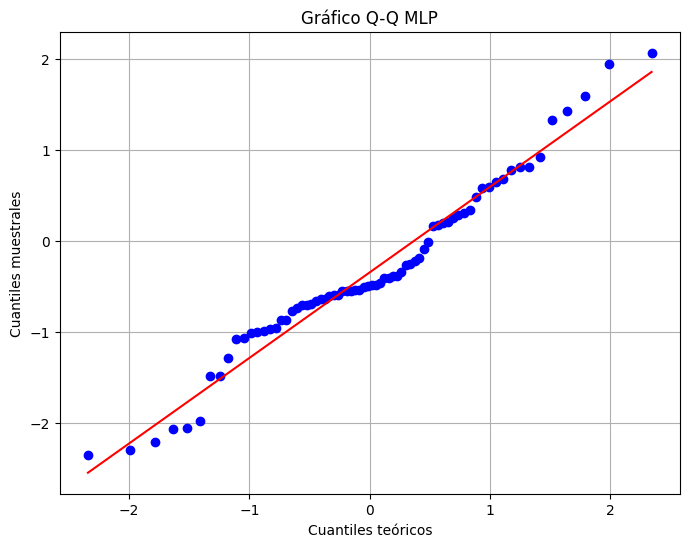

In [38]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

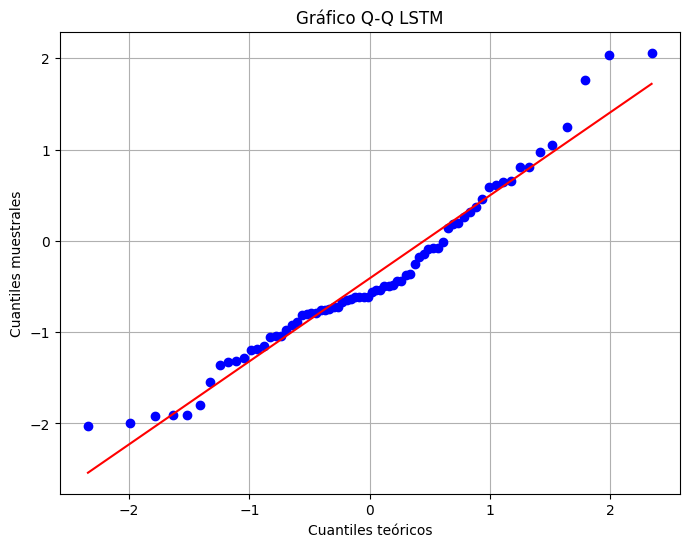

In [39]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

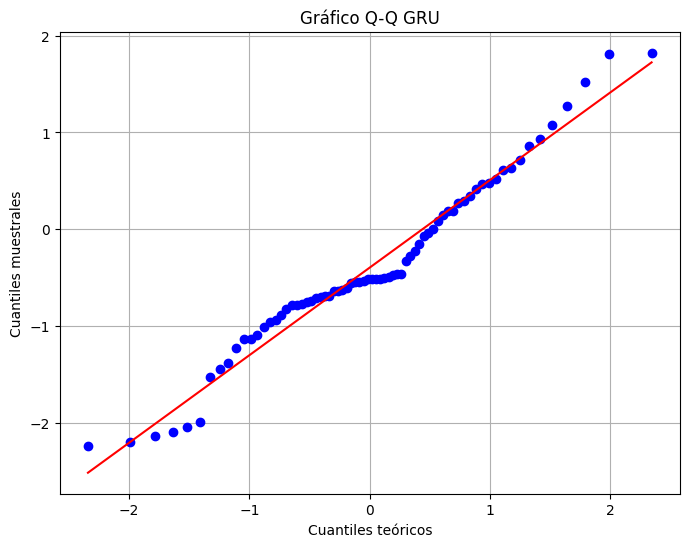

In [40]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

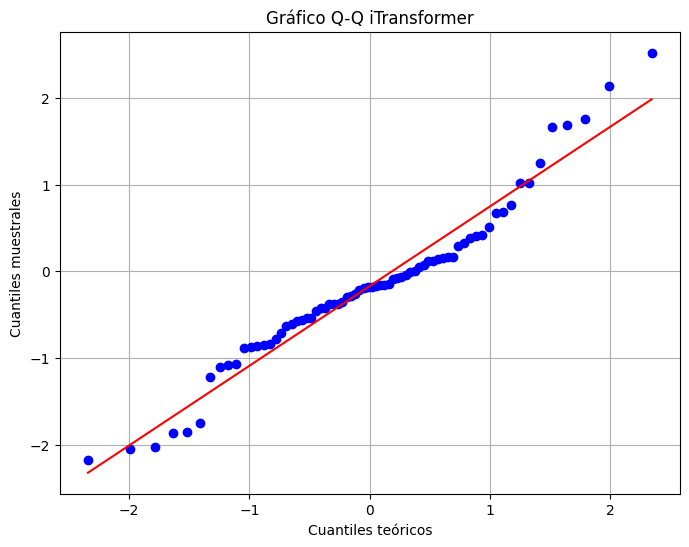

In [41]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

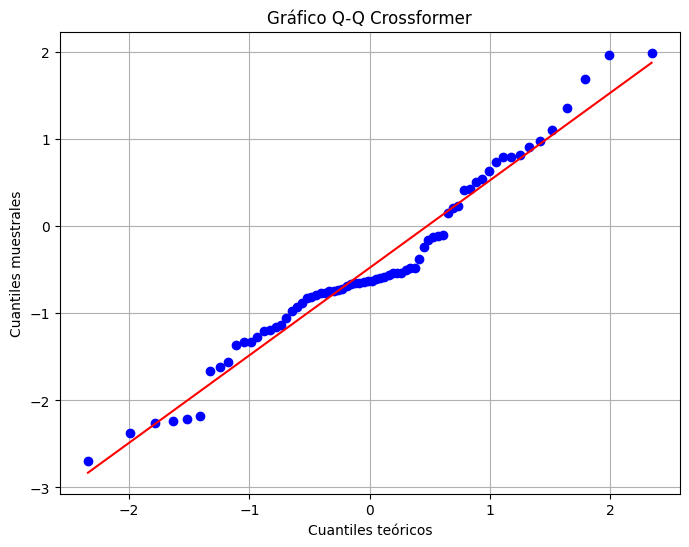

In [42]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

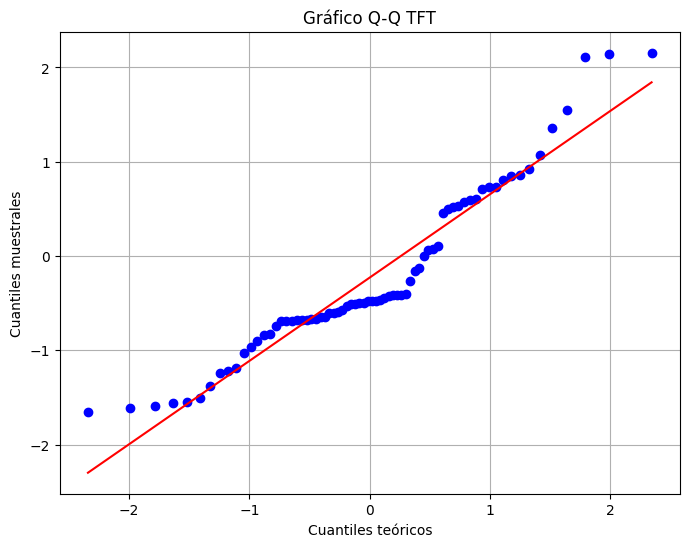

In [43]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico Q-Q TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

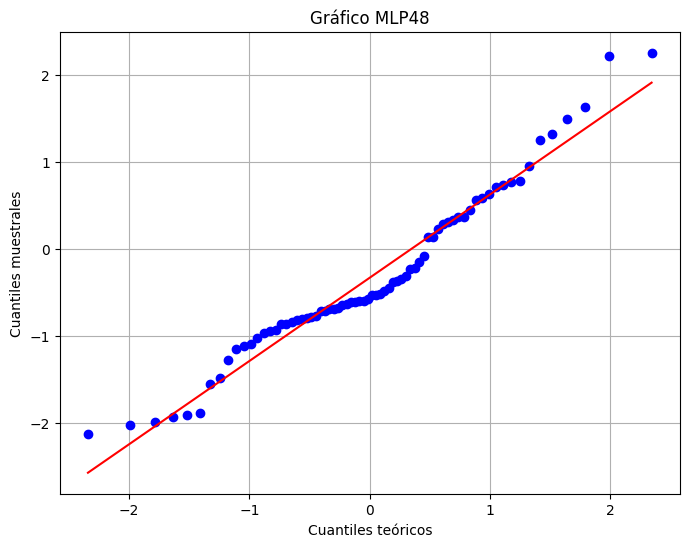

In [44]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP48"], dist="norm", plot=plt)
plt.title('Gráfico MLP48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

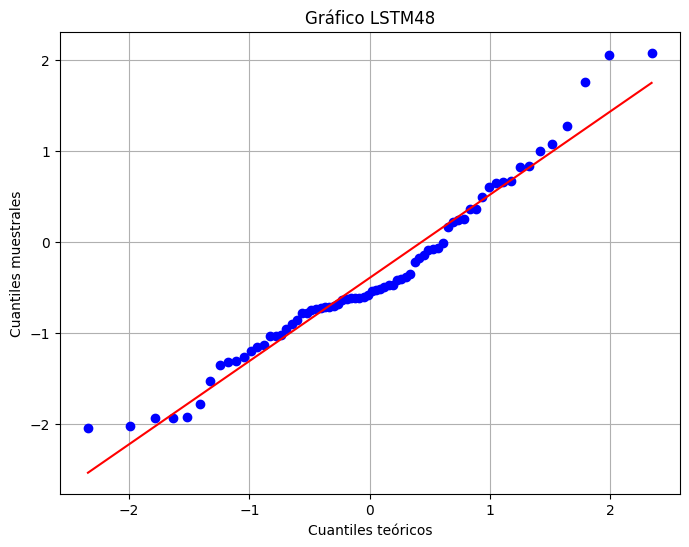

In [45]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM48"], dist="norm", plot=plt)
plt.title('Gráfico LSTM48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

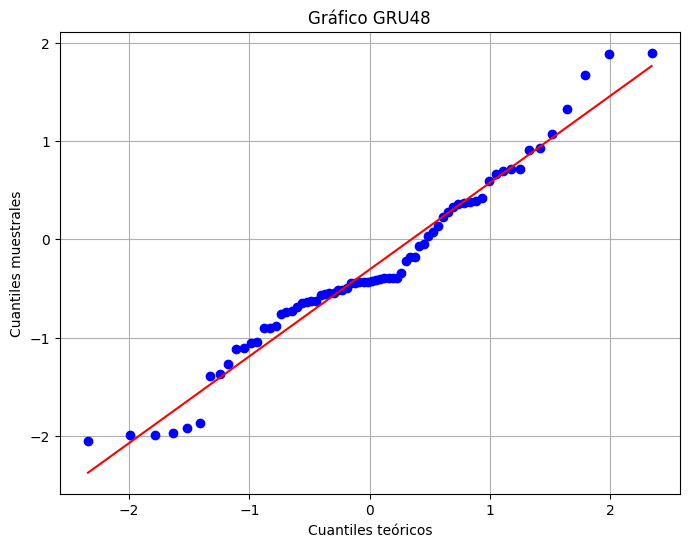

In [46]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU48"], dist="norm", plot=plt)
plt.title('Gráfico GRU48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

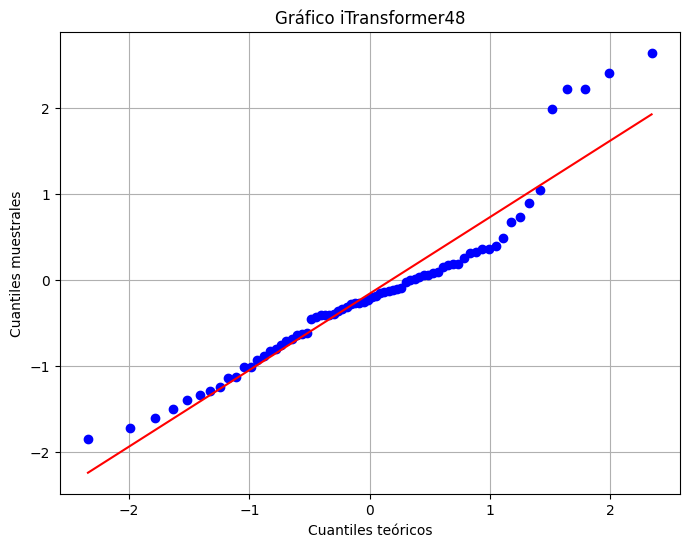

In [47]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer48"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

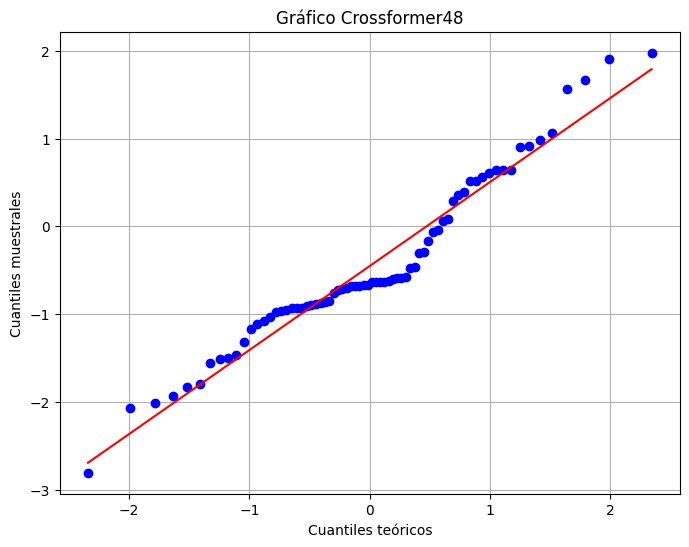

In [48]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer48"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

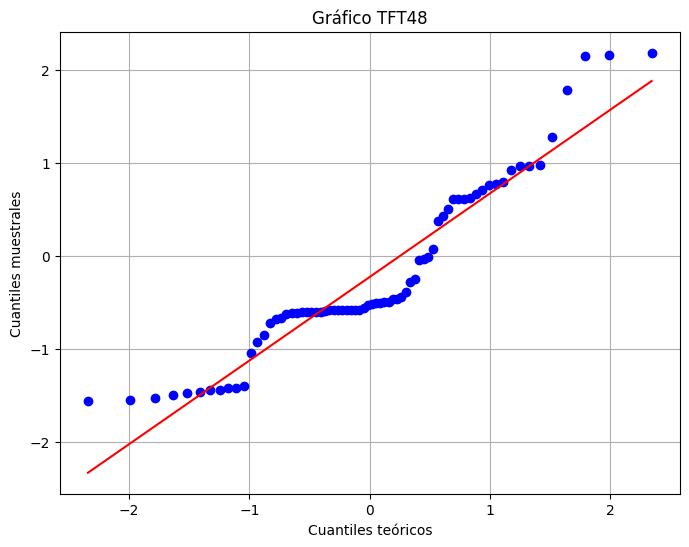

In [49]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT48"], dist="norm", plot=plt)
plt.title('Gráfico TFT48')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [50]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

2.5224973177488757e-08


In [53]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'MLP48'),
    ('LSTM', 'LSTM48'),
    ('GRU', 'GRU48'),
    ('Crossformer', 'Crossformer48'),
    ('iTransformer', 'iTransformer48'),
    ('TFT', 'TFT48'),
    ('MLP48', 'LSTM48'),
    ('MLP48', 'GRU48'),
    ('MLP48', 'Crossformer48'),
    ('MLP48', 'iTransformer48'),
    ('MLP48', 'TFT48'),
    ('LSTM48', 'GRU48'),
    ('LSTM48', 'Crossformer48'),
    ('LSTM48', 'iTransformer48'),
    ('LSTM48', 'TFT48'),
    ('GRU48', 'Crossformer48'),
    ('GRU48', 'iTransformer48'),
    ('GRU48', 'TFT48'),
    ('Crossformer48', 'iTransformer48'),
    ('Crossformer48', 'TFT48'),
    ('iTransformer48', 'TFT48'),
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs MLP48,0.57851,1.00000,1.00000
1,LSTM vs LSTM48,0.00000,0.00000,0.00000
2,GRU vs GRU48,0.00000,0.00000,0.00000
3,Crossformer vs Crossformer48,0.48301,1.00000,1.00000
4,iTransformer vs iTransformer48,0.59785,1.00000,1.00000
5,TFT vs TFT48,0.46226,1.00000,1.00000
6,MLP48 vs LSTM48,0.06324,1.00000,0.82218
7,MLP48 vs GRU48,0.28632,1.00000,1.00000
8,MLP48 vs Crossformer48,0.00028,0.00581,0.00415
9,MLP48 vs iTransformer48,0.31514,1.00000,1.00000
